In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
os.getcwd()
os.chdir('/Users/nitheshsrb/Documents/VSCode/Git/Fundamentals/weather_data')

In [15]:
df = pd.read_excel('open-meteo-51.49N0.16W23m.xlsx')

In [41]:
df.head()

2,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),snowfall_sum (cm),rain_sum (mm),precipitation_sum (mm),surface_pressure_mean (hPa),pressure_msl_mean (hPa),wind_gusts_10m_mean (km/h),...,pressure_msl_max (hPa),wet_bulb_temperature_2m_mean (°C),soil_temperature_0_to_100cm_mean (°C),soil_moisture_0_to_100cm_mean (m³/m³),year,month,Year-Month,max_temp_lag1,max_temp_lag1week,max_temp_lag52weeks
3,2018-01-01,6,7.3,4.6,0,2.3,2.3,996,998.8,36.7,...,1006.7,4.1,7.1,0.396,2018,1,2018 - 1,7.3,7.3,7.3
4,2018-01-02,7,12.2,2.3,0,7.7,7.7,1002,1004.8,42.1,...,1011.1,5.6,6.8,0.396,2018,1,2018 - 1,7.3,12.2,12.2
5,2018-01-03,8.4,12,6.8,0,1.8,1.8,993,995.7,62.4,...,1001.1,5.2,7.2,0.4,2018,1,2018 - 1,12.2,12,12
6,2018-01-04,8.2,12.6,5.8,0,4.4,4.4,991.8,994.5,41.4,...,1000.7,6.2,7.2,0.402,2018,1,2018 - 1,12,12.6,12.6
7,2018-01-05,5.4,8.5,1.9,0,0.8,0.8,991.8,994.6,27.5,...,999.4,3.9,7.1,0.404,2018,1,2018 - 1,12.6,8.5,8.5


In [11]:
df.dtypes

latitude                 object
longitude                object
elevation                object
utc_offset_seconds       object
timezone                 object
timezone_abbreviation    object
Unnamed: 6               object
Unnamed: 7               object
Unnamed: 8               object
Unnamed: 9               object
Unnamed: 10              object
Unnamed: 11              object
Unnamed: 12              object
Unnamed: 13              object
Unnamed: 14              object
Unnamed: 15              object
Unnamed: 16              object
Unnamed: 17              object
Unnamed: 18              object
Unnamed: 19              object
Unnamed: 20              object
dtype: object

In [18]:
df.describe()

2,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),snowfall_sum (cm),rain_sum (mm),precipitation_sum (mm),surface_pressure_mean (hPa),pressure_msl_mean (hPa),wind_gusts_10m_mean (km/h),...,et0_fao_evapotranspiration (mm),precipitation_hours (h),dew_point_2m_mean (°C),cloud_cover_mean (%),wind_speed_10m_mean (km/h),wind_speed_10m_max (km/h),pressure_msl_max (hPa),wet_bulb_temperature_2m_mean (°C),soil_temperature_0_to_100cm_mean (°C),soil_moisture_0_to_100cm_mean (m³/m³)
count,3043,3043.0,3043.0,3043.0,3043,3043,3043,3043.0,3043.0,3043.0,...,3043.00,3043,3043,3043,3043.0,3043.0,3043.0,3043.0,3043,3043.000
unique,3043,279.0,316.0,250.0,29,186,189,525.0,526.0,479.0,...,556.00,25,230,101,302.0,393.0,486.0,240.0,195,241.000
top,2018-01-01 00:00:00,9.3,12.6,5.8,0,0,0,1013.3,1015.2,26.2,...,0.34,0,6,100,11.1,16.6,1014.6,7.1,9,0.308
freq,1,31.0,47.0,44.0,2971,1216,1199,23.0,24.0,19.0,...,30.00,1199,39,153,32.0,26.0,22.0,34.0,37,52.000


In [17]:
df.columns = df.loc[2]
df = df.loc[3:]

In [19]:
df['time'] = pd.to_datetime(arg = df['time'], format = '%Y-%m-%d')

In [20]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['Year-Month'] = df['year'].astype('str') + ' - ' + df['month'].astype('str')

In [21]:
df['Year-Month'].head()

3    2018 - 1
4    2018 - 1
5    2018 - 1
6    2018 - 1
7    2018 - 1
Name: Year-Month, dtype: str

In [22]:
df[df['year'] == 2018]['temperature_2m_max (°C)'].sort_values(ascending=False)

209    32.7
210    30.9
220    30.2
217    30.2
206      30
       ... 
60      1.4
79      0.9
63      0.5
62      0.1
61     -0.7
Name: temperature_2m_max (°C), Length: 365, dtype: object

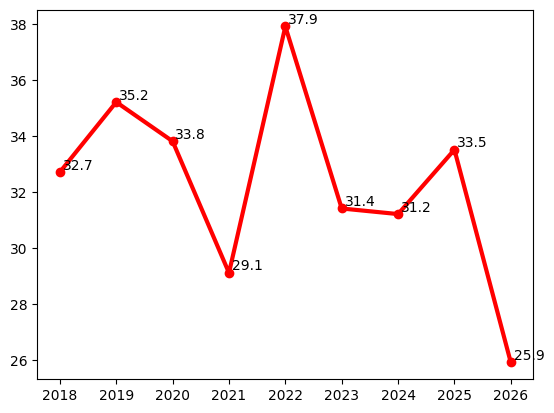

In [23]:
max_temp = df.groupby('year')['temperature_2m_max (°C)'].max().reset_index()

plt.plot(max_temp['year'],max_temp['temperature_2m_max (°C)'],linewidth = 3, color = 'red',marker = 'o')
for i, (year,val) in enumerate(zip(max_temp['year'],max_temp['temperature_2m_max (°C)'])):
    plt.annotate(str(val)
                 ,xy = (year,val)
                 , xytext = (2,2)
                 ,textcoords='offset points')

<Axes: ylabel='Density'>

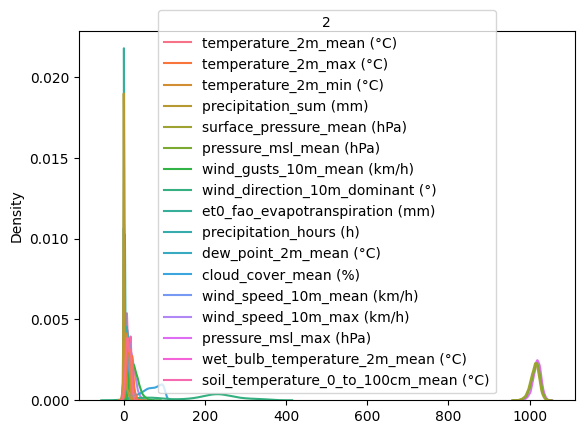

In [24]:
temp = df.drop(columns = ['snowfall_sum (cm)','rain_sum (mm)','year','month','soil_moisture_0_to_100cm_mean (m³/m³)'])
sns.kdeplot(data = temp)

<Axes: ylabel='Density'>

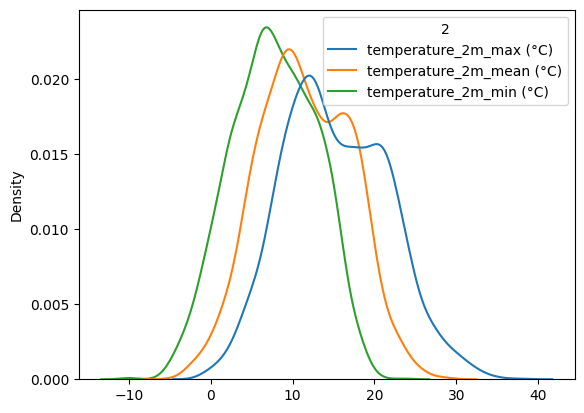

In [25]:
temperatures = df[['temperature_2m_max (°C)','temperature_2m_mean (°C)','temperature_2m_min (°C)']]
sns.kdeplot(data = temperatures)

In [26]:
df = df.sort_values(by='time',ascending=True)

df['max_temp_lag1'] = df['temperature_2m_max (°C)'].shift(1).fillna(df['temperature_2m_max (°C)'])
df['max_temp_lag1week'] = df['temperature_2m_max (°C)'].shift(7).fillna(df['temperature_2m_max (°C)'])
df['max_temp_lag52weeks'] = df['temperature_2m_max (°C)'].shift(365).fillna(df['temperature_2m_max (°C)'])



<Axes: xlabel='2', ylabel='2'>

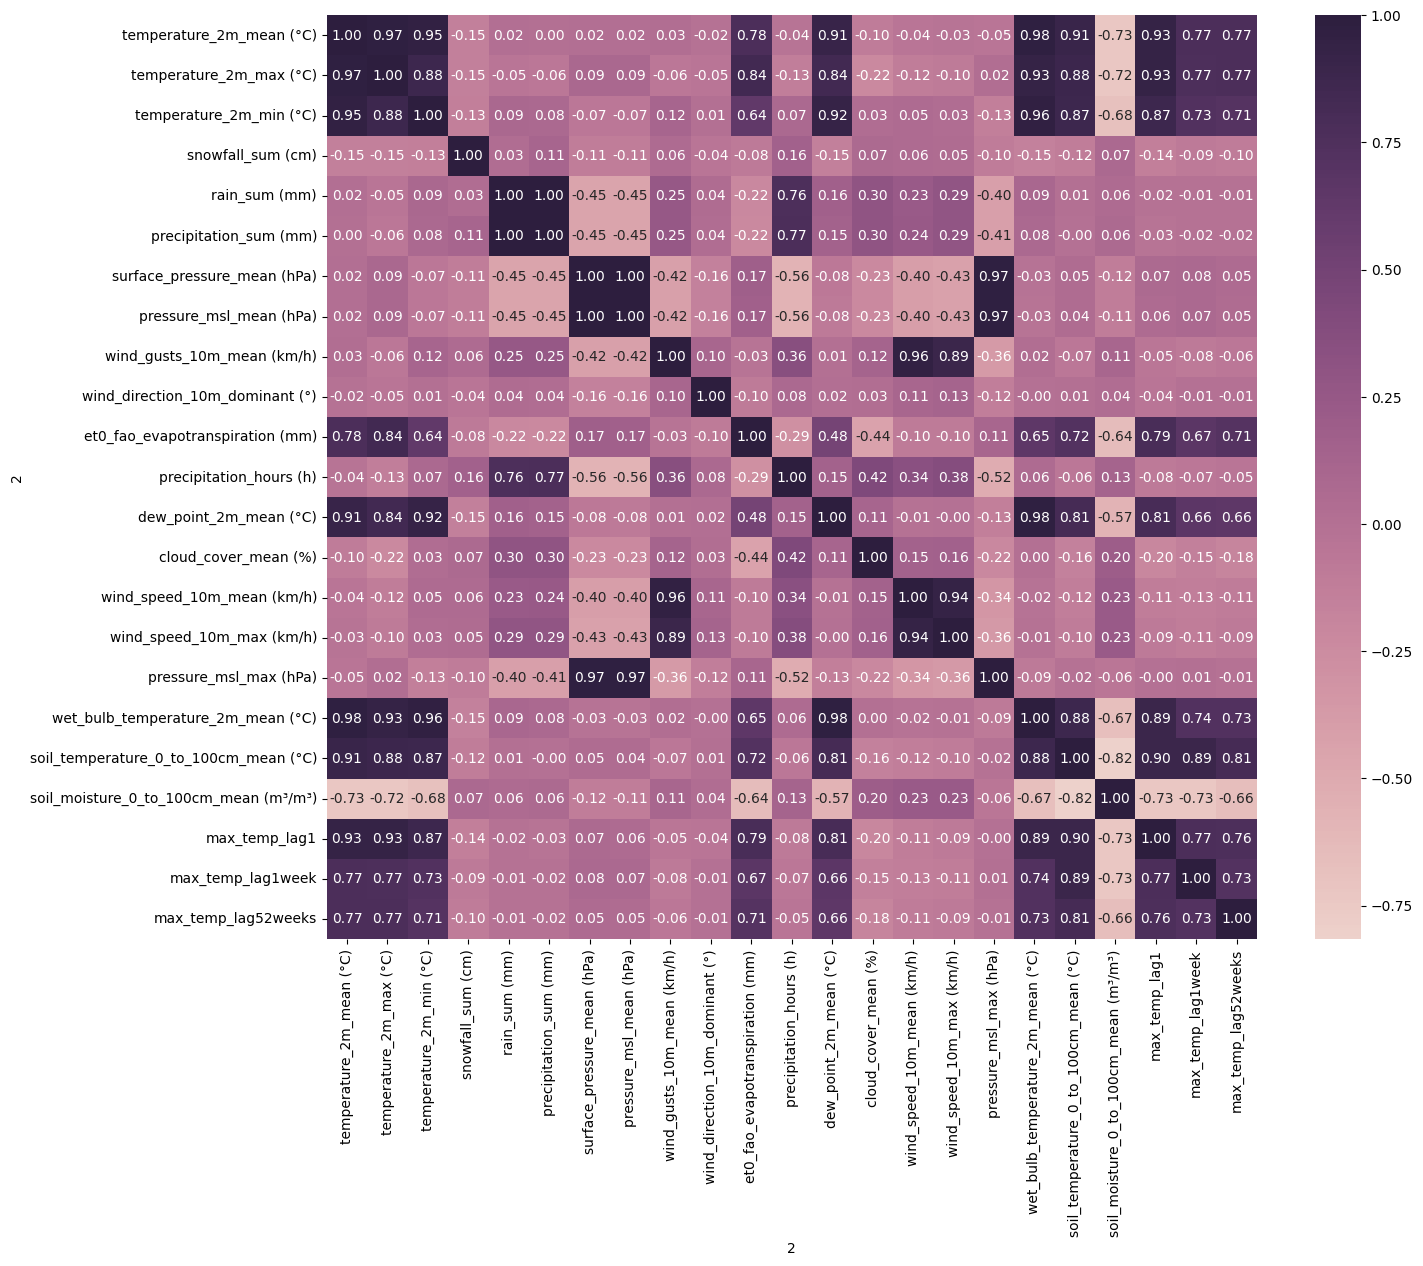

In [27]:
plt.figure(figsize = (15,12))
corr_df = df.drop(columns=['year','month','Year-Month','time'])

r = corr_df.corr()

sns.heatmap(data = r, cmap = sns.cubehelix_palette(as_cmap=True),fmt = '.2f',annot=True)

In [43]:
selected_features = ['dew_point_2m_mean (°C)','et0_fao_evapotranspiration (mm)','max_temp_lag1','max_temp_lag1week','max_temp_lag52weeks','soil_moisture_0_to_100cm_mean (m³/m³)','wet_bulb_temperature_2m_mean (°C)']

In [67]:
X_train = df[selected_features][df['time'] < pd.to_datetime('2025-01-01',format = '%Y-%m-%d')]
y_train = df['temperature_2m_max (°C)'][df['time'] < pd.to_datetime('2025-01-01',format = '%Y-%m-%d')]

X_test = df[selected_features][(df['time'] > pd.to_datetime('2025-01-01',format = '%Y-%m-%d')) & 
                                  (df['time'] < pd.to_datetime('2026-01-01',format = '%Y-%m-%d'))]
y_test = df['temperature_2m_max (°C)'][(df['time'] > pd.to_datetime('2025-01-01',format = '%Y-%m-%d')) & 
                                  (df['time'] < pd.to_datetime('2026-01-01',format = '%Y-%m-%d'))]

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [68]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
y_pred = model.predict(X_test)

In [70]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.9718456667983898
0.9452145300171085
1.1698183822128168


In [72]:
model.coef_

array([-0.20477099,  1.43973251,  0.07983534, -0.0196601 , -0.02737248,
       -4.16193291,  1.04673032])

In [73]:
import joblib
joblib.dump(model, filename='LinearRegression')

['LinearRegression']